In [5]:
import sys
import pathlib

raiz = pathlib.Path('..').resolve()
if str(raiz) not in sys.path:
    sys.path.insert(0, str(raiz))

import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150

from antenas import obtener_conjunto_backup
from generar_caso import generar_distancias

In [6]:
def medir(n_valores, k, b, D, reps=7):
    """Mide tiempos promedio (ms) para cada n, descartando min y max."""
    tiempos = []
    for n in n_valores:
        muestras = []
        for rep in range(reps):
            dist, _ = generar_distancias(n, seed=42 + rep)
            t0 = time.perf_counter()
            obtener_conjunto_backup(dist, k, b, D)
            t1 = time.perf_counter()
            muestras.append((t1 - t0) * 1000)
        muestras_filtradas = sorted(muestras)[1:-1]
        tiempos.append(sum(muestras_filtradas) / len(muestras_filtradas))
    return np.array(tiempos)

## Gráfico 1: curva medida vs ajustes cúbico y cuadrático

n=  5  0.0878 ms
n= 10  0.3354 ms
n= 20  1.3801 ms
n= 30  3.7547 ms
n= 50  13.9670 ms
n= 75  41.6387 ms
n=100  93.2544 ms
n=150  312.4016 ms
n=200  785.1386 ms

Ajuste cúbico:    C3 = 9.725e-05  →  f(n) = 9.725e-05·n³
Ajuste cuadrático: C2 = 1.766e-02  →  f(n) = 1.766e-02·n²

Guardado: C:\Users\Joaquin H\repos\tda_echeverria_tp2\informe\img\grafico_tiempos.png


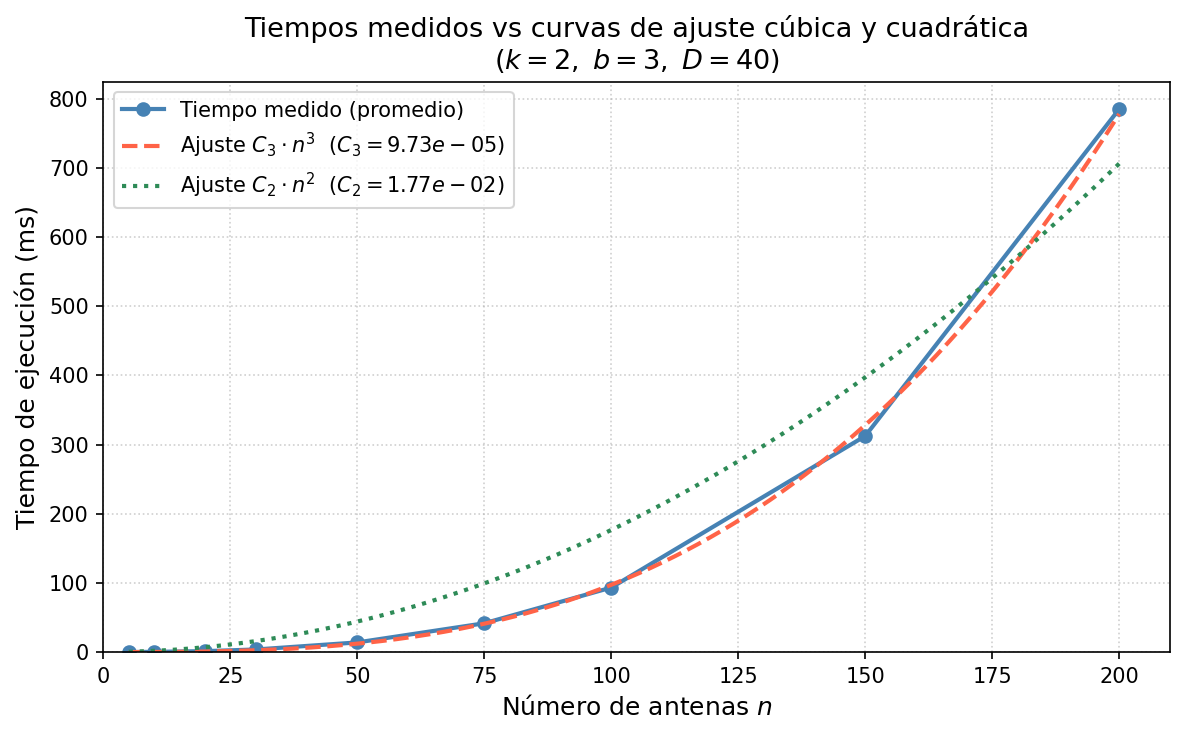

In [7]:
N_VALORES = [5, 10, 20, 30, 50, 75, 100, 150, 200]
K, B, D = 2, 3, 40.0

ns = np.array(N_VALORES, dtype=float)
ts = medir(N_VALORES, K, B, D)

for n, t in zip(N_VALORES, ts):
    print(f"n={n:>3}  {t:.4f} ms")

# Ajuste cúbico: f(n) = C3 * n^3 (sin término independiente)
C3, *_ = np.linalg.lstsq((ns**3).reshape(-1,1), ts, rcond=None)
C3 = C3[0]

# Ajuste cuadrático: f(n) = C2 * n^2 (sin término independiente)
C2, *_ = np.linalg.lstsq((ns**2).reshape(-1,1), ts, rcond=None)
C2 = C2[0]

print(f"\nAjuste cúbico:    C3 = {C3:.3e}  →  f(n) = {C3:.3e}·n³")
print(f"Ajuste cuadrático: C2 = {C2:.3e}  →  f(n) = {C2:.3e}·n²")

n_fino = np.linspace(ns[0], ns[-1], 500)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ns, ts, 'o-', color='steelblue', lw=2, ms=6, label='Tiempo medido (promedio)')
ax.plot(n_fino, C3 * n_fino**3, '--', color='tomato', lw=2, label=f'Ajuste $C_3\\cdot n^3$  ($C_3={C3:.2e}$)')
ax.plot(n_fino, C2 * n_fino**2, ':', color='seagreen', lw=2, label=f'Ajuste $C_2\\cdot n^2$  ($C_2={C2:.2e}$)')

ax.set_xlabel('Número de antenas $n$', fontsize=12)
ax.set_ylabel('Tiempo de ejecución (ms)', fontsize=12)
ax.set_title('Tiempos medidos vs curvas de ajuste cúbica y cuadrática\n($k=2,\\; b=3,\\; D=40$)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, linestyle=':', alpha=0.6)
ax.set_xlim(0, ns[-1]*1.05)
ax.set_ylim(bottom=0)
plt.tight_layout()

salida1 = pathlib.Path('../../informe/img/grafico_tiempos.png')
salida1.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(salida1, dpi=150, bbox_inches='tight')
print(f"\nGuardado: {salida1.resolve()}")
plt.show()

## Gráfico 2: efecto de k, b y D sobre los tiempos

Guardado: C:\Users\Joaquin H\repos\tda_echeverria_tp2\informe\img\grafico_tiempos_variables.png


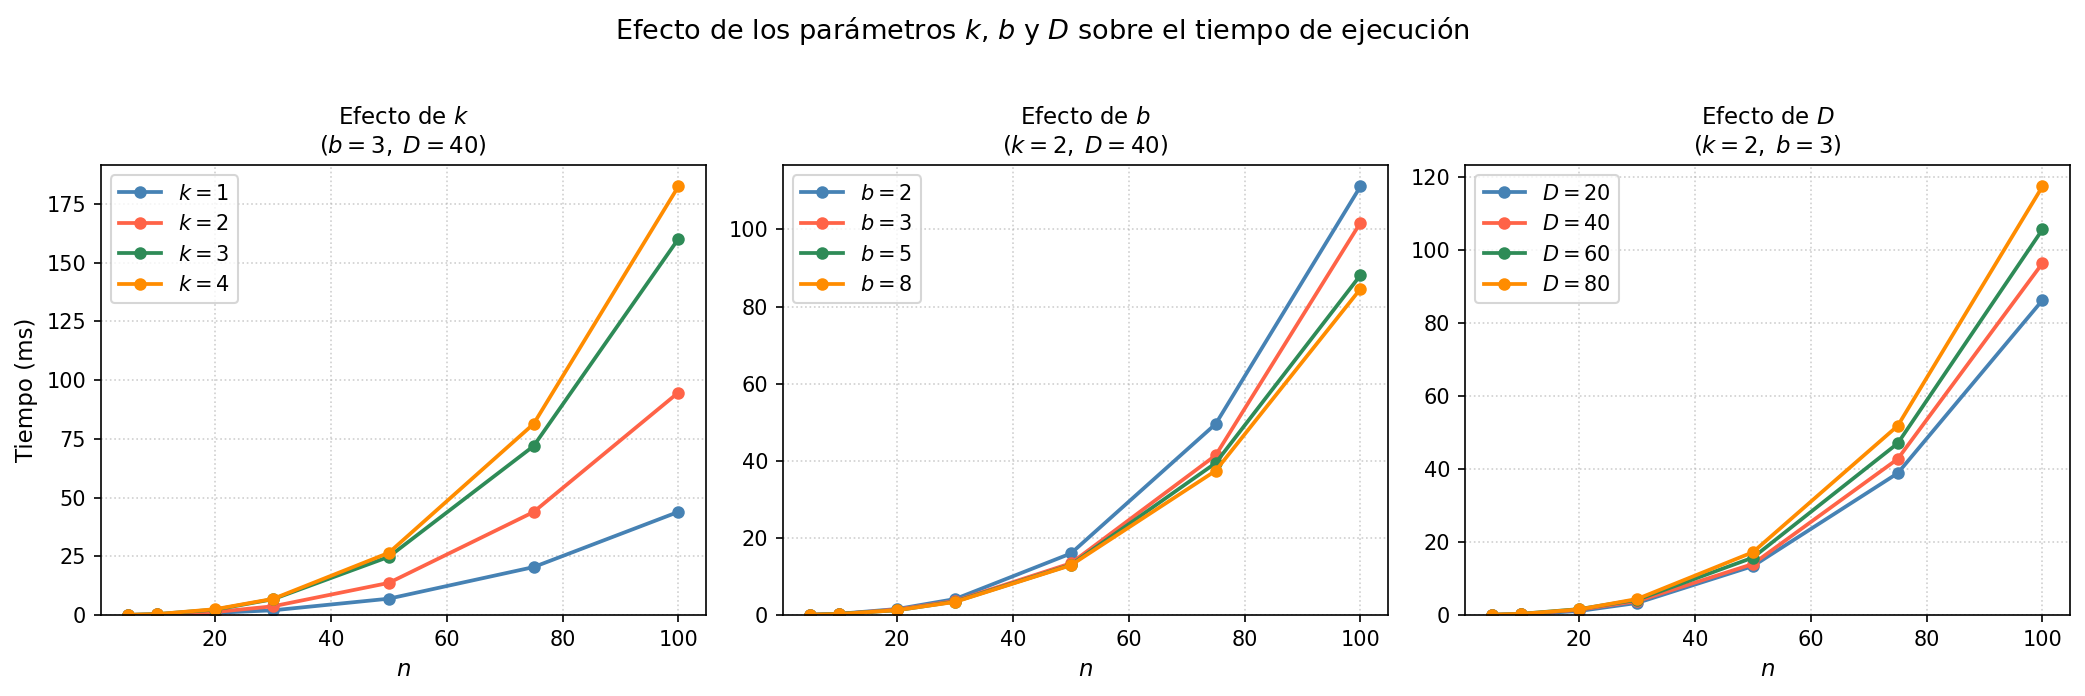

In [ ]:
N_VALS = [5, 10, 20, 30, 50, 75, 100]

# --- Variar k (b=3, D=40) ---
K_VALS = [1, 2, 3, 4]
datos_k = {k: medir(N_VALS, k, 3, 40.0) for k in K_VALS}

# --- Variar b (k=2, D=40) ---
B_VALS = [2, 3, 5, 8]
datos_b = {b: medir(N_VALS, 2, b, 40.0) for b in B_VALS}

# --- Variar D (k=2, b=3) ---
D_VALS = [20.0, 40.0, 60.0, 80.0]
datos_D = {d: medir(N_VALS, 2, 3, d) for d in D_VALS}

ns_p = np.array(N_VALS, dtype=float)
colores = ['steelblue', 'tomato', 'seagreen', 'darkorange']

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=False)

# Panel k
for (k, ts_k), color in zip(datos_k.items(), colores):
    axes[0].plot(ns_p, ts_k, 'o-', color=color, lw=1.8, ms=5, label=f'$k={k}$')
axes[0].set_title('Efecto de $k$\n($b=3,\\; D=40$)', fontsize=11)
axes[0].set_xlabel('$n$', fontsize=11)
axes[0].set_ylabel('Tiempo (ms)', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].set_ylim(bottom=0)

# Panel b
for (b, ts_b), color in zip(datos_b.items(), colores):
    axes[1].plot(ns_p, ts_b, 'o-', color=color, lw=1.8, ms=5, label=f'$b={b}$')
axes[1].set_title('Efecto de $b$\n($k=2,\\; D=40$)', fontsize=11)
axes[1].set_xlabel('$n$', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].set_ylim(bottom=0)

# Panel D
for (d, ts_d), color in zip(datos_D.items(), colores):
    axes[2].plot(ns_p, ts_d, 'o-', color=color, lw=1.8, ms=5, label=f'$D={d:.0f}$')
axes[2].set_title('Efecto de $D$\n($k=2,\\; b=3$)', fontsize=11)
axes[2].set_xlabel('$n$', fontsize=11)
axes[2].legend(fontsize=10)
axes[2].grid(True, linestyle=':', alpha=0.6)
axes[2].set_ylim(bottom=0)

plt.suptitle('Efecto de los parámetros $k$, $b$ y $D$ sobre el tiempo de ejecución', fontsize=13, y=1.02)
plt.tight_layout()
s
salida2 = pathlib.Path('../../informe/img/grafico_tiempos_variables.png')
plt.savefig(salida2, dpi=150, bbox_inches='tight')
print(f"Guardado: {salida2.resolve()}")
plt.show()